In [1]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica as pymodelica


# Run the simualtion

In [ ]:
MODEL_NAME = "System_LMO_exe"
EQUILIBRIUM_TIME = 20.0
PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"


# Step 1. a fast/coarse simulation to reach equilibrium
subprocess.run(
    [
        f"./{MODEL_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
    ],
    cwd="build",
    check=True
)



LOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K14 with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K4 with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K7 with a small value or zero.
|                 | |       | This could lead to

CompletedProcess(args=['./System_LMO_exe', '-lv=-LOG_STDOUT', '-overrideFile=../parameters/params_lmo_v1_mod_tes.txt', '-startTime=0', '-stopTime=20.0', '-stepSize=2e-4', '-tolerance=1e-8', '-s=dassl', '-w', '-outputFormat=mat', '-r=System_LMO_exe_res_init.mat', '-l=20.0'], returncode=0)

In [37]:

# Step 2: Compile another simulation with fine resolution starting from the final values of Step 1
# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
subprocess.run(
    [
        f"./{MODEL_NAME}",
        f"-r={MODEL_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="build",
    check=True
)


LOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K14 with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K4 with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_STDOUT        | warning | You are overriding K7 with a small value or zero.
|                 | |       | This could lead to

CompletedProcess(args=['./System_LMO_exe', '-r=System_LMO_exe_res_final.mat', '-overrideFile=../parameters/params_lmo_v1_mod_tes.txt', '-s=dassl', '-w', '-startTime=0', '-stopTime=0.1', '-stepSize=1e-6', '-tolerance=1e-8', '-iif=System_LMO_exe_res_init.mat', '-iit=20.0', '-lv=-LOG_STDOUT'], returncode=0)

In [38]:
filename = 'build/System_LMO_res_final.mat'

time_steps, data = pymodelica.load_om_mat(filename)
print(data.keys())

dict_keys(['L.i', 'glue.T', 'goldPadTES1.T', 'goldPadTES2.T', 'goldPadTarget.T', 'meander.T', 'silicon.T', 'target.T', 'tes.T', 'wireBond1.T', 'wireBond2.T', 'der(L.i)', 'der(glue.T)', 'der(goldPadTES1.T)', 'der(goldPadTES2.T)', 'der(goldPadTarget.T)', 'der(meander.T)', 'der(silicon.T)', 'der(target.T)', 'der(tes.T)', 'der(wireBond1.T)', 'der(wireBond2.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'RL.v', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow', 'g12.Q_flow', 'g13.Q_flow', 'g14.Q_flow', 'g2.Q_flow', 'g3.Q_flow', 'g4.Q_flow', 'g5.Q_flow', 'g6.Q_flow', 'g7.Q_flow', 'g8.Q_flow', 'g9.Q_flow', 'glue.cp', 'glue.port.Q_flow', 'goldPadTES1.cp', 'goldPadTES1.port.Q_flow', 'goldPadTES2.cp', 'goldPadTES2.por

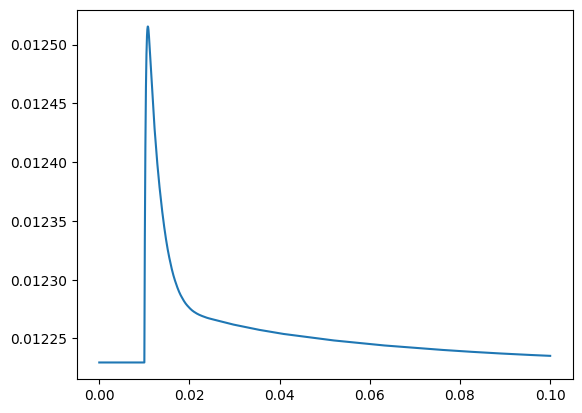

In [39]:
# plt.plot(time_steps, data['tes.i'])
plt.plot(time_steps, data['T2'])